# 01 – Weather Station EDA
**Question:** What data do we have, is it usable, and how do campus thermal conditions vary across space and time?
Data: hourly 2025 readings from 40 NUS campus weather stations (City Syntax Lab).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RAW = Path("../data/raw")
files = sorted(RAW.glob("NUS_CAMPUS_WS*_2025_Hourly.csv"))
print(len(files), "files found")

40 files found


In [3]:
frames = []
for f in files:
    d = pd.read_csv(f, parse_dates=["Datetime"])
    d["Station"] = f.name.split("_")[2]   # e.g. "WS01"
    frames.append(d)

df = pd.concat(frames, ignore_index=True)

print(df.shape)
display(df.head())
df.info()

(349590, 11)


,Datetime,Latitude,Longitude,WindSpeed Ave (m/s),WindDir Ave (degrees),AirTemp Ave (C),RelHum Ave (%),AtmPress Ave (hPa),GlobalRad Ave (W/m2),Station,Rain Tot (mm)
0,2025-01-01 00:00:00,1.300666,103.771232,0.517148,131.040439,25.782881,91.496610,1008.647458,0.0,WS01,NaN
1,2025-01-01 01:00:00,1.300666,103.771232,0.554134,131.457858,25.839000,91.136667,1008.288333,0.0,WS01,NaN
2,2025-01-01 02:00:00,1.300666,103.771232,0.729291,134.155274,25.766500,91.260000,1007.598333,0.0,WS01,NaN
3,2025-01-01 03:00:00,1.300666,103.771232,0.538654,133.938148,25.509500,92.063333,1006.823333,0.0,WS01,NaN
4,2025-01-01 04:00:00,1.300666,103.771232,0.499675,127.333428,25.353833,92.536667,1006.203333,0.0,WS01,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349590 entries, 0 to 349589
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Datetime               349590 non-null  datetime64[ns]
 1   Latitude               349590 non-null  float64       
 2   Longitude              349590 non-null  float64       
 3   WindSpeed Ave (m/s)    335381 non-null  float64       
 4   WindDir Ave (degrees)  335381 non-null  float64       
 5   AirTemp Ave (C)        335381 non-null  float64       
 6   RelHum Ave (%)         335381 non-null  float64       
 7   AtmPress Ave (hPa)     335381 non-null  float64       
 8   GlobalRad Ave (W/m2)   325335 non-null  float64       
 9   Station                349590 non-null  object        
 10  Rain Tot (mm)          26280 non-null   float64       
dtypes: datetime64[ns](1), float64(9), object(1)
memory usage: 29.3+ MB


In [4]:
## 03. Dataset structure
df = df.rename(columns={
    "Datetime": "datetime",
    "Latitude": "lat",
    "Longitude": "lon",
    "WindSpeed Ave (m/s)": "wind_speed",
    "WindDir Ave (degrees)": "wind_dir",
    "AirTemp Ave (C)": "temp",
    "RelHum Ave (%)": "rh",
    "AtmPress Ave (hPa)": "pressure",
    "GlobalRad Ave (W/m2)": "solar",
    "Rain Tot (mm)": "rain",
})
df.columns.tolist()

['datetime',
 'lat',
 'lon',
 'wind_speed',
 'wind_dir',
 'temp',
 'rh',
 'pressure',
 'solar',
 'Station',
 'rain']

In [5]:
station_summary = (
    df.groupby("Station")
      .agg(rows=("datetime", "size"),
           first=("datetime", "min"),
           last=("datetime", "max"),
           lat=("lat", "first"),
           lon=("lon", "first"),
           n_locations=("lat", "nunique"))
)
station_summary["missing_rows"] = 8760 - station_summary["rows"]

print("Stations:", df["Station"].nunique())
print("Date range:", df["datetime"].min(), "→", df["datetime"].max())
display(station_summary.sort_values("missing_rows", ascending=False))

Stations: 40
Date range: 2025-01-01 00:00:00 → 2025-12-31 23:00:00


,rows,first,last,lat,lon,n_locations,missing_rows
Station,,,,,,,
WS38,8325,2025-01-01 00:00:00,2025-12-13 20:00:00,1.305473,103.773064,1,435
WS06,8443,2025-01-01 00:00:00,2025-12-18 18:00:00,1.298318,103.770400,1,317
WS17,8717,2025-01-01 00:00:00,2025-12-30 04:00:00,1.292331,103.774516,1,43
WS31,8748,2025-01-01 12:00:00,2025-12-31 23:00:00,1.296682,103.780151,1,12
WS20,8758,2025-01-01 00:00:00,2025-12-31 21:00:00,1.292916,103.779062,1,2
WS30,8759,2025-01-01 00:00:00,2025-12-31 22:00:00,1.295731,103.779872,1,1
WS01,8760,2025-01-01 00:00:00,2025-12-31 23:00:00,1.300666,103.771232,1,0
WS25,8760,2025-01-01 00:00:00,2025-12-31 23:00:00,1.297994,103.777999,1,0
WS26,8760,2025-01-01 00:00:00,2025-12-31 23:00:00,1.298145,103.777511,1,0


In [6]:
key = ["temp", "rh", "wind_speed", "wind_dir", "pressure", "solar"]
(df[key].isna().mean() * 100).round(2)

temp          4.06
rh            4.06
wind_speed    4.06
wind_dir      4.06
pressure      4.06
solar         6.94
dtype: float64

In [7]:
miss_station = (df[key].isna().groupby(df["Station"]).mean() * 100).round(1)
display(miss_station.sort_values("temp", ascending=False).head(10))

,temp,rh,wind_speed,wind_dir,pressure,solar
Station,,,,,,
WS11,26.6,26.6,26.6,26.6,26.6,26.6
WS34,21.1,21.1,21.1,21.1,21.1,21.1
WS32,19.5,19.5,19.5,19.5,19.5,10.5
WS14,16.4,16.4,16.4,16.4,16.4,15.9
WS07,11.2,11.2,11.2,11.2,11.2,11.3
WS33,10.2,10.2,10.2,10.2,10.2,10.2
WS17,9.7,9.7,9.7,9.7,9.7,9.6
WS15,9.3,9.3,9.3,9.3,9.3,9.3
WS31,8.4,8.4,8.4,8.4,8.4,8.4


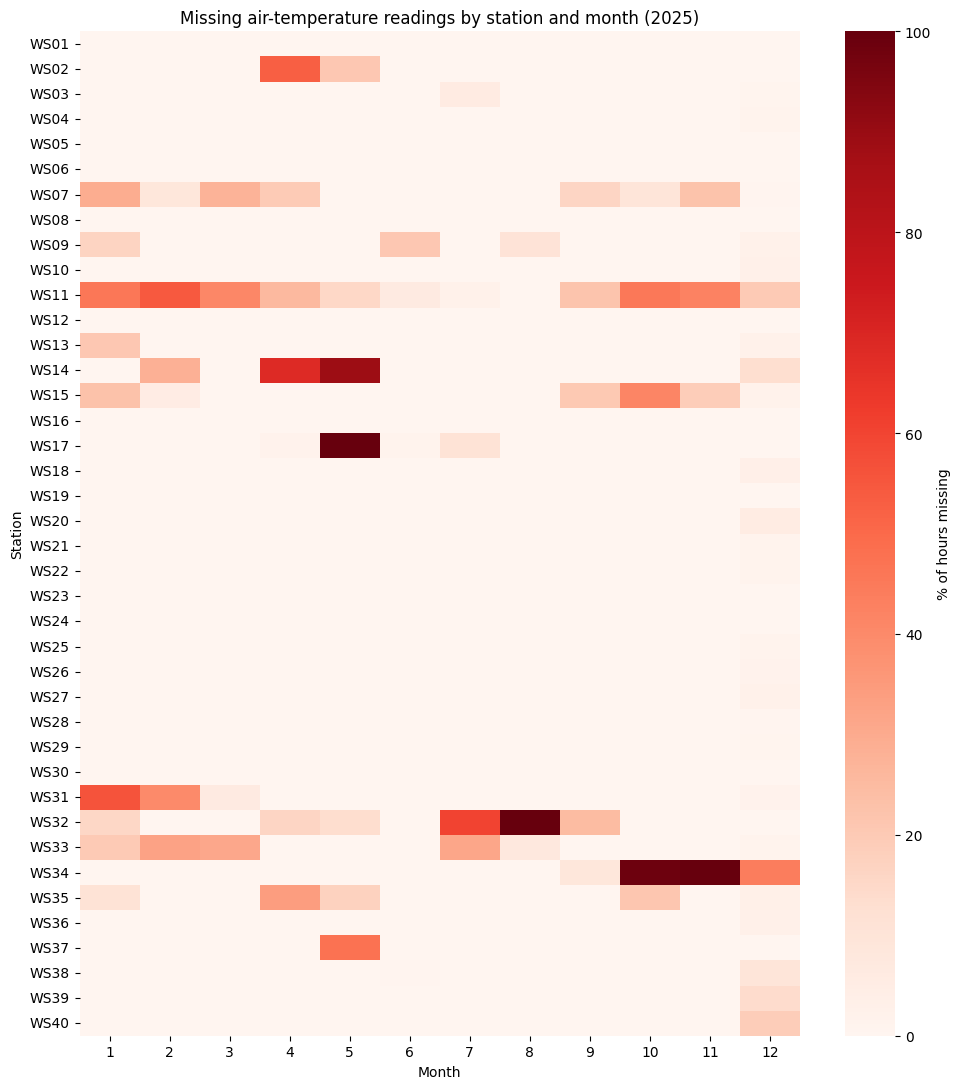

In [8]:
df["month"] = df["datetime"].dt.month
miss_month = (df["temp"].isna()
                .groupby([df["Station"], df["month"]]).mean()
                .unstack() * 100)

plt.figure(figsize=(10, 11))
sns.heatmap(miss_month, cmap="Reds", vmin=0, vmax=100,
            cbar_kws={"label": "% of hours missing"})
plt.title("Missing air-temperature readings by station and month (2025)")
plt.xlabel("Month")
plt.ylabel("Station")
plt.tight_layout()
plt.show()